In [2]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import

In [ ]:
import ipywidgets as widgets
import sys
import os
import shap
import pickle
import traceback
import importlib
import xgboost as xgb
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

from pathlib import Path
from collections import defaultdict
from sklearn.metrics.pairwise import rbf_kernel
from scipy.stats import ks_2samp
from interpret import show
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.svm import LinearSVC, SVC
from interpret.blackbox import ShapKernel
from interpret.blackbox import LimeTabular
from interpret.blackbox import PartialDependence
import ipywidgets as widgets
from IPython.display import display
from xai_manager import XAIManager
from sklearn.metrics import (roc_curve, auc, classification_report, accuracy_score, roc_auc_score, average_precision_score, precision_recall_curve)
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate, false_negative_rate
from IPython.display import HTML
import importlib
import xai_manager

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 5000)       # big enough for 383 columns
pd.set_option('display.max_colwidth', None)


module_path='preprocessing/day_intervals_preproc'
if module_path not in sys.path:
    sys.path.append(module_path)

module_path='utils'
if module_path not in sys.path:
    sys.path.append(module_path)

module_path='preprocessing/hosp_module_preproc'
if module_path not in sys.path:
    sys.path.append(module_path)

module_path='model'
if module_path not in sys.path:
    sys.path.append(module_path)
#print(sys.path)
root_dir = os.path.dirname(os.path.abspath('UserInterface.ipynb'))
import day_intervals_cohort
from day_intervals_cohort import *

import day_intervals_cohort_v2
from day_intervals_cohort_v2 import *

import data_generation_icu

import data_generation
import evaluation

import feature_selection_hosp
from feature_selection_hosp import *

# import train
# from train import *

import ml_models
from ml_models import *

import dl_train
from dl_train import *

import tokenization
from tokenization import *


import behrt_train
from behrt_train import *

import feature_selection_icu
from feature_selection_icu import *
import fairness
import callibrate_output

In [3]:
importlib.reload(day_intervals_cohort)
import day_intervals_cohort
from day_intervals_cohort import *

importlib.reload(day_intervals_cohort_v2)
import day_intervals_cohort_v2
from day_intervals_cohort_v2 import *

importlib.reload(data_generation_icu)
import data_generation_icu
importlib.reload(data_generation)
import data_generation

importlib.reload(feature_selection_hosp)
import feature_selection_hosp
from feature_selection_hosp import *

importlib.reload(feature_selection_icu)
import feature_selection_icu
from feature_selection_icu import *

importlib.reload(tokenization)
import tokenization
from tokenization import *

importlib.reload(ml_models)
import ml_models
from ml_models import *

importlib.reload(dl_train)
import dl_train
from dl_train import *

importlib.reload(behrt_train)
import behrt_train
from behrt_train import *

importlib.reload(fairness)
import fairness

importlib.reload(callibrate_output)
import callibrate_output

importlib.reload(evaluation)
import evaluation

# Final MIMIC-IV Project - Unison Park and Brianna Gamble

This repository provides step-by-step instructions to download, preprocess, and clean the MIMIC-IV dataset for downstream analysis.
It is compatible with both MIMIC-IV v1.0 and v2.0 and is best run with Python 3.9.8.

Please go to:
- https://physionet.org/content/mimiciv/1.0/ for v1.0
- https://physionet.org/content/mimiciv/2.0/ for v2.0

Follow instructions to get access to MIMIC-IV dataset.

Download the files using your terminal:
- wget -r -N -c -np --user mehakg --ask-password https://physionet.org/files/mimiciv/1.0/ or
- wget -r -N -c -np --user mehakg --ask-password https://physionet.org/files/mimiciv/2.0/


Save downloaded files in the parent directory of this github repo.

The structure should look like below for v1.0-
- mimiciv/1.0/core
- mimiciv/1.0/hosp
- mimiciv/1.0/icu

The structure should look like below for v2.0-
- mimiciv/2.0/hosp
- mimiciv/2.0/icu

## 1. DATA EXTRACTION
Please run below cell to select **Version 2** as the Mimic-IV data use and **Length of Stay** for Prediction Task. 
The cohort will be saved in **./data/cohort/**

In [4]:
print("Please select the approriate version of MIMIC-IV for which you have downloaded data ?")
version = widgets.RadioButtons(options=['Version 1','Version 2'],value='Version 2')
display(version)

print("Please select what prediction task you want to perform ?")
radio_input4 = widgets.RadioButtons(options=['Mortality','Length of Stay','Readmission','Phenotype'],value='Length of Stay')
display(radio_input4)


Please select the approriate version of MIMIC-IV for which you have downloaded data ?


RadioButtons(index=1, options=('Version 1', 'Version 2'), value='Version 2')

Please select what prediction task you want to perform ?


RadioButtons(index=1, options=('Mortality', 'Length of Stay', 'Readmission', 'Phenotype'), value='Length of St…

### Refining Cohort and Prediction Task Definition

Based on your current selection following block will provide option to further refine prediction task and cohort associated with it:

- First you will refine the prediction task choosing -
    - **length of Stay** - 7 days

    - **Phenotype Prediction** - No Disease Filter

- Second, you will choose to perfom above task using **ICU admissions data**
    
print("**Please run below cell to extract the cohort for selected options**")

In [5]:
if radio_input4.value=='Length of Stay':
    radio_input2 = widgets.RadioButtons(options=['Length of Stay ge 3','Length of Stay ge 7','Custom'],value='Length of Stay ge 7')
    display(radio_input2)
    text1=widgets.IntSlider(
    value=3,
    min=1,
    max=10,
    step=1,
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)
    display(widgets.HBox([widgets.Label('Length of stay ge (in days)',layout={'width': '180px'}), text1]))
elif radio_input4.value=='Readmission':
    radio_input2 = widgets.RadioButtons(options=['30 Day Readmission','60 Day Readmission','90 Day Readmission','120 Day Readmission','Custom'],value='30 Day Readmission')
    display(radio_input2)
    text1=widgets.IntSlider(
    value=30,
    min=10,
    max=150,
    step=10,
    disabled=False
    )
    display(widgets.HBox([widgets.Label('Readmission after (in days)',layout={'width': '180px'}), text1]))
elif radio_input4.value=='Phenotype':
    radio_input2 = widgets.RadioButtons(options=['Heart Failure in 30 days','CAD in 30 days','CKD in 30 days','COPD in 30 days'],value='Heart Failure in 30 days')
    display(radio_input2)
elif radio_input4.value=='Mortality':
    radio_input2 = widgets.RadioButtons(options=['Mortality'],value='Mortality')
    #display(radio_input2)

print("Extract Data")
print("Please select below if you want to work with ICU or Non-ICU data ?")
radio_input1 = widgets.RadioButtons(options=['ICU', 'Non-ICU'],value='ICU')
display(radio_input1)

print("Please select if you want to perform choosen prediction task for a specific disease.")
radio_input3 = widgets.RadioButtons(options=['No Disease Filter','Heart Failure','CKD','CAD','COPD'],value='No Disease Filter')
display(radio_input3)

RadioButtons(index=1, options=('Length of Stay ge 3', 'Length of Stay ge 7', 'Custom'), value='Length of Stay …

Extract Data
Please select below if you want to work with ICU or Non-ICU data ?


RadioButtons(options=('ICU', 'Non-ICU'), value='ICU')

Please select if you want to perform choosen prediction task for a specific disease.


RadioButtons(options=('No Disease Filter', 'Heart Failure', 'CKD', 'CAD', 'COPD'), value='No Disease Filter')

In [6]:
disease_label=""
time=0
label=radio_input4.value

if label=='Readmission':
    if radio_input2.value=='Custom':
        time=text1.value
    else:
        time=int(radio_input2.value.split()[0])
elif label=='Length of Stay':
    if radio_input2.value=='Custom':
        time=text1.value
    else:
        time=int(radio_input2.value.split()[4])

if label=='Phenotype':
    if radio_input2.value=='Heart Failure in 30 days':
        label='Readmission'
        time=30
        disease_label='I50'
    elif radio_input2.value=='CAD in 30 days':
        label='Readmission'
        time=30
        disease_label='I25'
    elif radio_input2.value=='CKD in 30 days':
        label='Readmission'
        time=30
        disease_label='N18'
    elif radio_input2.value=='COPD in 30 days':
        label='Readmission'
        time=30
        disease_label='J44'

data_icu=radio_input1.value=="ICU"
data_mort=label=="Mortality"
data_admn=label=='Readmission'
data_los=label=='Length of Stay'


if (radio_input3.value=="Heart Failure"):
    icd_code='I50'
elif (radio_input3.value=="CKD"):
    icd_code='N18'
elif (radio_input3.value=="COPD"):
    icd_code='J44'
elif (radio_input3.value=="CAD"):
    icd_code='I25'
else:
    icd_code='No Disease Filter'

if version.value=='Version 1':
    version_path="mimiciv/1.0"
    cohort_output = day_intervals_cohort.extract_data(radio_input1.value,label,time,icd_code, root_dir,disease_label)
elif version.value=='Version 2':
    version_path="mimiciv/2.0"
    cohort_output = day_intervals_cohort_v2.extract_data(radio_input1.value,label,time,icd_code, root_dir,disease_label)

===========MIMIC-IV v2.0============
EXTRACTING FOR: | ICU | LENGTH OF STAY | 7 |
[ LOS LABELS FINISHED ]
[ COHORT SUCCESSFULLY SAVED ]
[ SUMMARY SUCCESSFULLY SAVED ]
Length of Stay FOR ICU DATA
# Admission Records: 39329
# Patients: 28022
# Positive cases: 4327
# Negative cases: 35002


## 2. FEATURE SELECTION
Please Select only **Diagnoses, Procedures, Medications, and Chart Events** to include for cohort

All features will be saved in **./data/features/**

**Please run below cell to select features**

In [7]:
print("Feature Selection")
if data_icu:
    print("Which Features you want to include for cohort?")
    check_input1 = widgets.Checkbox(description='Diagnosis')
    display(check_input1)
    check_input2 = widgets.Checkbox(description='Output Events')
    display(check_input2)
    check_input3 = widgets.Checkbox(description='Chart Events(Labs and Vitals)')
    display(check_input3)
    check_input4 = widgets.Checkbox(description='Procedures')
    display(check_input4)
    check_input5 = widgets.Checkbox(description='Medications')
    display(check_input5)
else:
    print("Which Features you want to include for cohort?")
    check_input1 = widgets.Checkbox(description='Diagnosis')
    display(check_input1)
    check_input2 = widgets.Checkbox(description='Labs')
    display(check_input2)
    check_input3 = widgets.Checkbox(description='Procedures')
    display(check_input3)
    check_input4 = widgets.Checkbox(description='Medications')
    display(check_input4)
print("**Please run below cell to extract selected features**")

Feature Selection
Which Features you want to include for cohort?


Checkbox(value=False, description='Diagnosis')

Checkbox(value=False, description='Output Events')

Checkbox(value=False, description='Chart Events(Labs and Vitals)')

Checkbox(value=False, description='Procedures')

Checkbox(value=False, description='Medications')

**Please run below cell to extract selected features**


In [8]:
if data_icu:
    diag_flag=check_input1.value
    out_flag=check_input2.value
    chart_flag=check_input3.value
    proc_flag=check_input4.value
    med_flag=check_input5.value
    feature_icu(cohort_output, version_path,diag_flag,out_flag,chart_flag,proc_flag,med_flag)
else:
    diag_flag=check_input1.value
    lab_flag=check_input2.value
    proc_flag=check_input3.value
    med_flag=check_input4.value
    feature_nonicu(cohort_output, version_path,diag_flag,lab_flag,proc_flag,med_flag)

[EXTRACTING DIAGNOSIS DATA]
# unique ICD-9 codes 5684
# unique ICD-10 codes 8112
# unique ICD-10 codes (After converting ICD-9 to ICD-10) 8442
# unique ICD-10 codes (After clinical gruping ICD-10 codes) 1427
# Admissions:   39317
Total rows 687984
[SUCCESSFULLY SAVED DIAGNOSIS DATA]
[EXTRACTING CHART EVENTS DATA]


33it [02:17,  4.16s/it]


# Unique Events:   451
# Admissions:   39322
Total rows 41463212
[SUCCESSFULLY SAVED CHART EVENTS DATA]
[EXTRACTING PROCEDURES DATA]
# Unique Events:   157
# Admissions:   39084
Total rows 370087
[SUCCESSFULLY SAVED PROCEDURES DATA]
[EXTRACTING MEDICATIONS DATA]
# of unique type of drug:  184
# Admissions:   37127
# Total rows 2607659
[SUCCESSFULLY SAVED MEDICATIONS DATA]


## 3. CLINICAL GROUPING
Below you will have to **Convert ICD-9 to ICD-10 and group ICD-10 codes.**
Grouping medical codes will reduce dimensional space of features.

Default options selected below will group medical codes to reduce feature dimension space.

**Please run below cell to select preprocessing for diferent features**

In [9]:
if data_icu:
    if diag_flag:
        print("Do you want to group ICD 10 DIAG codes ?")
        radio_input4 = widgets.RadioButtons(options=['Keep both ICD-9 and ICD-10 codes','Convert ICD-9 to ICD-10 codes','Convert ICD-9 to ICD-10 and group ICD-10 codes'],value='Convert ICD-9 to ICD-10 and group ICD-10 codes',layout={'width': '100%'})
        display(radio_input4)

else:
    if diag_flag:
        print("Do you want to group ICD 10 DIAG codes ?")
        radio_input4 = widgets.RadioButtons(options=['Keep both ICD-9 and ICD-10 codes','Convert ICD-9 to ICD-10 codes','Convert ICD-9 to ICD-10 and group ICD-10 codes'],value='Convert ICD-9 to ICD-10 and group ICD-10 codes',layout={'width': '100%'})
        display(radio_input4)
    if med_flag:
        print("Do you want to group Medication codes to use Non propietary names?")
        radio_input5 = widgets.RadioButtons(options=['Yes','No'],value='Yes',layout={'width': '100%'})
        display(radio_input5)
    if proc_flag:
        print("Which ICD codes for Procedures you want to keep in data?")
        radio_input6 = widgets.RadioButtons(options=['ICD-9 and ICD-10','ICD-10'],value='ICD-10',layout={'width': '100%'})
        display(radio_input6)
print("**Please run below cell to perform feature preprocessing**")

Do you want to group ICD 10 DIAG codes ?


RadioButtons(index=2, layout=Layout(width='100%'), options=('Keep both ICD-9 and ICD-10 codes', 'Convert ICD-9…

**Please run below cell to perform feature preprocessing**


In [10]:
group_diag=False
group_med=False
group_proc=False
if data_icu:
    if diag_flag:
        group_diag=radio_input4.value
    preprocess_features_icu(cohort_output, diag_flag, group_diag,False,False,False,0,0)
else:
    if diag_flag:
        group_diag=radio_input4.value
    if med_flag:
        group_med=radio_input5.value
    if proc_flag:
        group_proc=radio_input6.value
    preprocess_features_hosp(cohort_output, diag_flag,proc_flag,med_flag,False,group_diag,group_med,group_proc,False,False,0,0)

[PROCESSING DIAGNOSIS DATA]
Total number of rows 651219
[SUCCESSFULLY SAVED DIAGNOSIS DATA]


### 4. SUMMARY OF FEATURES

This step will generate summary of all features extracted so far.<br>
It will save summary files in **./data/summary/**<br>
- These files provide summary about **mean frequency** of medical codes per admission.<br>
- It also provides **total occurrence count** of each medical code.<br>
- For labs and chart events it will also provide <br>**missing %** which tells how many rows for a certain medical code has missing value.

Please use this information to further refine your cohort by selecting <br>which medical codes in each feature you want to keep and <br>which codes you would like to remove for downstream analysis tasks.

**Please run below cell to generate summary files**

In [11]:
if data_icu:
    generate_summary_icu(diag_flag,proc_flag,med_flag,out_flag,chart_flag)
else:
    generate_summary_hosp(diag_flag,proc_flag,med_flag,lab_flag)

[GENERATING FEATURE SUMMARY]
[SUCCESSFULLY SAVED FEATURE SUMMARY]


## 5. Feature Selection

based on the files generated in previous step and other infromation gathered by you,<br>

Please run below cell to to select -  **No** for all the codes in a feature.

In [12]:
if data_icu:
    if diag_flag:
        print("Do you want to do Feature Selection for Diagnosis \n (If yes, please edit list of codes in ./data/summary/diag_features.csv)")
        radio_input4 = widgets.RadioButtons(options=['Yes','No'],value='No')
        display(radio_input4)
    if med_flag:
        print("Do you want to do Feature Selection for Medication \n (If yes, please edit list of codes in ./data/summary/med_features.csv)")
        radio_input5 = widgets.RadioButtons(options=['Yes','No'],value='No')
        display(radio_input5)
    if proc_flag:
        print("Do you want to do Feature Selection for Procedures \n (If yes, please edit list of codes in ./data/summary/proc_features.csv)")
        radio_input6 = widgets.RadioButtons(options=['Yes','No'],value='No')
        display(radio_input6)
    if out_flag:
        print("Do you want to do Feature Selection for Output event \n (If yes, please edit list of codes in ./data/summary/out_features.csv)")
        radio_input7 = widgets.RadioButtons(options=['Yes','No'],value='No')
        display(radio_input7)
    if chart_flag:
        print("Do you want to do Feature Selection for Chart events \n (If yes, please edit list of codes in ./data/summary/chart_features.csv)")
        radio_input8 = widgets.RadioButtons(options=['Yes','No'],value='No')
        display(radio_input8)
else:
    if diag_flag:
        print("Do you want to do Feature Selection for Diagnosis \n (If yes, please edit list of codes in ./data/summary/diag_features.csv)")
        radio_input4 = widgets.RadioButtons(options=['Yes','No'],value='No')
        display(radio_input4)
    if med_flag:
        print("Do you want to do Feature Selection for Medication \n (If yes, please edit list of codes in ./data/summary/med_features.csv)")
        radio_input5 = widgets.RadioButtons(options=['Yes','No'],value='No')
        display(radio_input5)
    if proc_flag:
        print("Do you want to do Feature Selection for Procedures \n (If yes, please edit list of codes in ./data/summary/proc_features.csv)")
        radio_input6 = widgets.RadioButtons(options=['Yes','No'],value='No')
        display(radio_input6)
    if lab_flag:
        print("Do you want to do Feature Selection for Labs \n (If yes, please edit list of codes in ./data/summary/lab_features.csv)")
        radio_input7 = widgets.RadioButtons(options=['Yes','No'],value='No')
        display(radio_input7)
print("**Please run below cell to perform feature selection**")

Do you want to do Feature Selection for Diagnosis 
 (If yes, please edit list of codes in ./data/summary/diag_features.csv)


RadioButtons(index=1, options=('Yes', 'No'), value='No')

Do you want to do Feature Selection for Medication 
 (If yes, please edit list of codes in ./data/summary/med_features.csv)


RadioButtons(index=1, options=('Yes', 'No'), value='No')

Do you want to do Feature Selection for Procedures 
 (If yes, please edit list of codes in ./data/summary/proc_features.csv)


RadioButtons(index=1, options=('Yes', 'No'), value='No')

Do you want to do Feature Selection for Chart events 
 (If yes, please edit list of codes in ./data/summary/chart_features.csv)


RadioButtons(index=1, options=('Yes', 'No'), value='No')

**Please run below cell to perform feature selection**


In [13]:
select_diag=False
select_med=False
select_proc=False
select_lab=False
select_out=False
select_chart=False

if data_icu:
    if diag_flag:
        select_diag=radio_input4.value == 'Yes'
    if med_flag:
        select_med=radio_input5.value == 'Yes'
    if proc_flag:
        select_proc=radio_input6.value == 'Yes'
    if out_flag:
        select_out=radio_input7.value == 'Yes'
    if chart_flag:
        select_chart=radio_input8.value == 'Yes'
    features_selection_icu(cohort_output, diag_flag,proc_flag,med_flag,out_flag, chart_flag,select_diag,select_med,select_proc,select_out,select_chart)
else:
    if diag_flag:
        select_diag=radio_input4.value == 'Yes'
    if med_flag:
        select_med=radio_input5.value == 'Yes'
    if proc_flag:
        select_proc=radio_input6.value == 'Yes'
    if lab_flag:
        select_lab=radio_input7.value == 'Yes'
    features_selection_hosp(cohort_output, diag_flag,proc_flag,med_flag,lab_flag,select_diag,select_med,select_proc,select_lab)

## 6. CLEANING OF FEATURES
Below you will have option to to clean lab and chart events by performing outlier removal and unit conversion.

Outlier removal is performed to remove values higher than selected **right threshold** percentile and lower than selected **left threshold** percentile among all values for each itemid. 

Please perform outlier removal of **right outer threshold of 98 and left threshold of 2.**

**Please run below cell to select preprocessing for diferent features**

In [14]:
if data_icu:
    if chart_flag:
        print("Outlier removal in values of chart events ?")
        layout = widgets.Layout(width='100%', height='40px') #set width and height

        radio_input5 = widgets.RadioButtons(options=['No outlier detection','Impute Outlier (default:98)','Remove outliers (default:98)'],value='No outlier detection',layout=layout)
        display(radio_input5)
        outlier=widgets.IntSlider(
        value=98,
        min=90,
        max=99,
        step=1,
        disabled=False,layout={'width': '100%'}
        )
        left_outlier=widgets.IntSlider(
        value=0,
        min=0,
        max=10,
        step=1,
        disabled=False,layout={'width': '100%'}
        )
        #display(oulier)
        display(widgets.HBox([widgets.Label('Right Outlier Threshold',layout={'width': '150px'}), outlier]))
        display(widgets.HBox([widgets.Label('Left Outlier Threshold',layout={'width': '150px'}), left_outlier]))

else:
    if lab_flag:
        print("Outlier removal in values of lab events ?")
        layout = widgets.Layout(width='100%', height='40px') #set width and height

        radio_input7 = widgets.RadioButtons(options=['No outlier detection','Impute Outlier (default:98)','Remove outliers (default:98)'],value='No outlier detection',layout=layout)
        display(radio_input7)
        outlier=widgets.IntSlider(
        value=98,
        min=90,
        max=99,
        step=1,
        disabled=False,layout={'width': '100%'}
        )
        left_outlier=widgets.IntSlider(
        value=0,
        min=0,
        max=10,
        step=1,
        disabled=False,layout={'width': '100%'}
        )
        #display(oulier)
        display(widgets.HBox([widgets.Label('Right Outlier Threshold',layout={'width': '150px'}), outlier]))
        display(widgets.HBox([widgets.Label('Left Outlier Threshold',layout={'width': '150px'}), left_outlier]))
print("**Please run below cell to perform feature preprocessing**")

Outlier removal in values of chart events ?


RadioButtons(layout=Layout(height='40px', width='100%'), options=('No outlier detection', 'Impute Outlier (def…

**Please run below cell to perform feature preprocessing**


In [15]:
thresh=0
if data_icu:
    if chart_flag:
        clean_chart=radio_input5.value!='No outlier detection'
        impute_outlier_chart=radio_input5.value=='Impute Outlier (default:98)'
        thresh=outlier.value
        left_thresh=left_outlier.value
        preprocess_features_icu(cohort_output, False, False,chart_flag,clean_chart,impute_outlier_chart,thresh,left_thresh)
    else:
        preprocess_features_icu(cohort_output, False, False,False,False,False,0,0)
else:
    if lab_flag:
        clean_lab=radio_input7.value!='No outlier detection'
        impute_outlier=radio_input7.value=='Impute Outlier (default:98)'
        thresh=outlier.value
        left_thresh=left_outlier.value
    preprocess_features_hosp(cohort_output, False,False,False,lab_flag,False,False,False,clean_lab,impute_outlier,thresh,left_thresh)

[PROCESSING CHART EVENTS DATA]
Total number of rows 41463153
[SUCCESSFULLY SAVED CHART EVENTS DATA]


## 7. Time-Series Representation
In this section, please choose to process and represent time-series data.

- Select the length of time-series data of **first 12 hours** for this study. 

- Secondly, select **3 bucket size** which tells in what size time windows you want to divide your time-series.<br>


### Imputation
 The imputation will be done by **forward fill and median imputation.**<br>
Values will be forward fill first and if no value exists for that admission we will use mean or median value for the patient.

The data dictionaries will be saved in **./data/dict/**

Please refer the readme to know the structure of data dictionaries.

**Please run below cell to select time-series representation**

In [16]:
print("=======Time-series Data Represenation=======")

print("Length of data to be included for time-series prediction ?")
if(data_mort):
    radio_input8 = widgets.RadioButtons(options=['First 72 hours','First 48 hours','First 24 hours','Custom'],value='First 72 hours')
    display(radio_input8)
    text2=widgets.IntSlider(
    value=72,
    min=24,
    max=72,
    step=1,
    description='Fisrt',
    disabled=False
    )
    display(widgets.HBox([widgets.Label('Fisrt (in hours):',layout={'width': '150px'}), text2]))
elif(data_admn):
    radio_input8 = widgets.RadioButtons(options=['Last 72 hours','Last 48 hours','Last 24 hours','Custom'],value='Last 72 hours')
    display(radio_input8)
    text2=widgets.IntSlider(
    value=72,
    min=24,
    max=72,
    step=1,
    description='Last',
    disabled=False
    )
    display(widgets.HBox([widgets.Label('Last (in hours):',layout={'width': '150px'}), text2]))
elif(data_los):
    radio_input8 = widgets.RadioButtons(options=['First 12 hours','First 24 hours','Custom'],value='First 12 hours')
    display(radio_input8)
    text2=widgets.IntSlider(
    value=72,
    min=12,
    max=72,
    step=1,
    description='First',
    disabled=False
    )
    display(widgets.HBox([widgets.Label('Fisrt (in hours):',layout={'width': '150px'}), text2]))


print("What time bucket size you want to choose ?")
radio_input7 = widgets.RadioButtons(options=['1 hour','2 hour','3 hour','4 hour','5 hour','Custom'],value='3 hour')
display(radio_input7)
text1=widgets.IntSlider(
    value=1,
    min=1,
    max=6,
    step=1,
    disabled=False
    )
#display(text1)
display(widgets.HBox([widgets.Label('Bucket Size (in hours):',layout={'width': '150px'}), text1]))
print("Do you want to forward fill and mean or median impute lab/chart values to form continuous data signal?")
radio_impute = widgets.RadioButtons(options=['No Imputation', 'forward fill and mean','forward fill and median'],value='forward fill and median')
display(radio_impute)

radio_input6 = widgets.RadioButtons(options=['0 hours','2 hours','4 hours','6 hours'],value='0 hours')
if(data_mort):
    print("If you have choosen mortality prediction task, then what prediction window length you want to keep?")
    radio_input6 = widgets.RadioButtons(options=['2 hours','4 hours','6 hours','8 hours','Custom'],value='3 hours')
    display(radio_input6)
    text3=widgets.IntSlider(
    value=2,
    min=2,
    max=8,
    step=1,
    disabled=False
    )
    display(widgets.HBox([widgets.Label('Prediction window (in hours)',layout={'width': '180px'}), text3]))
print("**Please run below cell to perform time-series represenation and save in data dictionaries**")

=======Time-series Data Represenation=======
Length of data to be included for time-series prediction ?


RadioButtons(options=('First 12 hours', 'First 24 hours', 'Custom'), value='First 12 hours')

What time bucket size you want to choose ?


RadioButtons(index=2, options=('1 hour', '2 hour', '3 hour', '4 hour', '5 hour', 'Custom'), value='3 hour')

Do you want to forward fill and mean or median impute lab/chart values to form continuous data signal?


RadioButtons(index=2, options=('No Imputation', 'forward fill and mean', 'forward fill and median'), value='fo…

**Please run below cell to perform time-series represenation and save in data dictionaries**


In [17]:
if (radio_input6.value=='Custom'):
    predW=int(text3.value)
else:
    predW=int(radio_input6.value[0].strip())
if (radio_input7.value=='Custom'):
    bucket=int(text1.value)
else:
    bucket=int(radio_input7.value[0].strip())
if (radio_input8.value=='Custom'):
    include=int(text2.value)
else:
    include=int(radio_input8.value.split()[1])
if (radio_impute.value=='forward fill and mean'):
    impute='Mean'
elif (radio_impute.value=='forward fill and median'):
    impute='Median'
else:
    impute=False

if data_icu:
    gen=data_generation_icu.Generator(cohort_output,data_mort,data_admn,data_los,diag_flag,proc_flag,out_flag,chart_flag,med_flag,impute,include,bucket,predW)
    #gen=data_generation_icu.Generator(cohort_output,data_mort,diag_flag,False,False,chart_flag,False,impute,include,bucket,predW)
    #if chart_flag:
    #    gen=data_generation_icu.Generator(cohort_output,data_mort,False,False,False,chart_flag,False,impute,include,bucket,predW)
else:
    gen=data_generation.Generator(cohort_output,data_mort,data_admn,data_los,diag_flag,lab_flag,proc_flag,med_flag,impute,include,bucket,predW)

[ READ COHORT ]
[ ======READING DIAGNOSIS ]
[ ======READING PROCEDURES ]
[ ======READING CHART EVENTS ]


9it [01:11,  7.92s/it]


[ ======READING MEDICATIONS ]
[ READ ALL FEATURES ]
include_time 12
[ PROCESSED TIME SERIES TO EQUAL LENGTH  ]


100%|██████████| 4/4 [00:00<00:00,  4.98it/s]


bucket 3
[ PROCESSED TIME SERIES TO EQUAL TIME INTERVAL ]
4


100%|██████████| 37688/37688 [1:50:49<00:00,  5.67it/s]  


[ SUCCESSFULLY SAVED DATA DICTIONARIES ]


### Feature Dictionary
A unified feature dictionary across demographics, diagnoses, medications, procedures, chart events, and labels. It enriches each feature with human-readable names sourced from MIMIC-IV reference tables so that downstream explainability methods can display clear, interpretable feature names instead of raw codes. 

In [ ]:
from pathlib import Path
from utils.feature_dictionary import build_feature_dictionary

# Assuming you open the notebook from the project root folder
PROJECT_ROOT = Path(".").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "csv"
OUTPUT_DIR = PROJECT_ROOT / "data" / "output"

feature_dict = build_feature_dictionary(
    demo_path=DATA_DIR / "demo_all.csv",
    labels_path=DATA_DIR / "labels.csv",
    static_path=DATA_DIR / "static_all.csv",
    dynamic_path=DATA_DIR / "dynamic_all.csv",
    root_dir=PROJECT_ROOT,   # <- used inside feature_dictionary.py for MIMIC paths
    out_dir=OUTPUT_DIR,
)

feature_dict.head()


## 8. Machine Learning Models

Below we provide options to select -
- Type of machine learning model (Logistic Regression, Xgboost, and Linear SVM)
Below select 
- **Concatenate** time-series features.
- **No CV** cross validation 


In [19]:
print("=======Machine:Learning Models=======")
radio_input5 = widgets.RadioButtons(options=['Logistic Regression','Xgboost', 'Linear SVM'], value='Xgboost')
display(radio_input5)

print("Do you want to concatenate the time-series feature?")
# Fixed typo: 'Conactenate' -> 'Concatenate'
radio_input6 = widgets.RadioButtons(options=['Concatenate','Aggregate'], value='Concatenate')
display(radio_input6)

print("Please select below option for cross-validation")
# Recommendation: select 5-fold to ensure code works but is faster than 10-fold
radio_input7 = widgets.RadioButtons(options=['No CV','5-fold CV','10-fold CV'], value='No CV')
display(radio_input7)

print("Do you want to do oversampling for minority class?")
# Fixed typo: 'calss' -> 'class'
radio_input8 = widgets.RadioButtons(options=['True','False'], value='False')
display(radio_input8)

=======Machine:Learning Models=======


RadioButtons(index=1, options=('Logistic Regression', 'Xgboost', 'Linear SVM'), value='Xgboost')

Do you want to concatenate the time-series feature?


RadioButtons(options=('Concatenate', 'Aggregate'), value='Concatenate')

Please select below option for cross-validation


RadioButtons(options=('No CV', '5-fold CV', '10-fold CV'), value='No CV')

Do you want to do oversampling for minority class?


RadioButtons(index=1, options=('True', 'False'), value='False')

In [71]:
import ml_models
import importlib
# 1. Reload the library to ensure it sees your latest changes to ml_models.py
importlib.reload(ml_models)

# 2. Extract values from the Widgets
selected_model_name = radio_input5.value  
feature_method = radio_input6.value          
k_fold_val = 0
# 3. Convert Widget Strings to Logic Variables
# Handle Feature Engineering Method
if feature_method == 'Concatenate':
    concat_bool = True
else:
    concat_bool = False

# 4. EXECUTE THE MODEL
print(f"Starting execution with:")
print(f"Model: {selected_model_name}")
print(f"Concat: {concat_bool}")
print(f"CV: {k_fold_val}")
print("-" * 30)

ml_instance = ml_models.ML_models(
    data_icu=True, 
    k_fold=k_fold_val,        # Set True/False based on your dataset
    model_type=selected_model_name, # Passed from widget
    concat=concat_bool)     # Passed from widget
print("Execution Complete.")

Starting execution with:
Model: Xgboost
Concat: True
CV: 0
------------------------------
Total Samples 37688
Positive Samples 4327
Finished reading all data files......
Processing Fold 0
Train IDs: 25625, Val IDs: 4523, Test IDs: 7537
Start processing features
Start processing features
Start processing features
Saved CSVs for fold 0 successfully.

Starting Hyperparameter Tuning...
Preprocessing features...
Data ready. Training shape: (25625, 432)
--------------------------------------------------
1. Tuning XGBoost...
   Base Scale Pos Weight: 7.78
Fitting 5 folds for each of 40 candidates, totalling 200 fits
   Best Params (CV): {'subsample': 0.6, 'scale_pos_weight': 3.8893456663240835, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 1, 'colsample_bytree': 0.8}
   Best CV Score (AUPRC): 0.4180
   Refitting best XGB on full training data (no early stopping)...
Artifacts saved successfully.
-------------------

In [72]:
%run predict_next.py

Loading Data & Preprocessor...

EVALUATING: XGBoost
AU-ROC:      0.8375
AU-PRC:      0.4145
Accuracy:    0.8612
Precision:   0.4243
Recall:      0.4910
Specificity: 0.9108
NPV:         0.9304
BCE Loss:    0.3246
ECE:         0.1013
MCE:         0.2504

EVALUATING: Logistic Regression
AU-ROC:      0.8118
AU-PRC:      0.3688
Accuracy:    0.7718
Precision:   0.3005
Recall:      0.7022
Specificity: 0.7811
NPV:         0.9514
BCE Loss:    0.5145
ECE:         0.2474
MCE:         0.4543

EVALUATING: Linear SVM
AU-ROC:      0.8123
AU-PRC:      0.3687
Accuracy:    0.7740
Precision:   0.3014
Recall:      0.6933
Specificity: 0.7849
NPV:         0.9503
BCE Loss:    0.5697
ECE:         0.3192
MCE:         0.3539


In [73]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def threshold_sensitivity_analysis(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.1, 0.9, 9)

    records = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        rec = recall_score(y_true, y_pred)              # sensitivity
        prec = precision_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        records.append({
            "threshold": t,
            "precision": prec,
            "recall_sensitivity": rec,
            "specificity": specificity,
            "f1": f1,
            "TP": tp,
            "FP": fp,
            "TN": tn,
            "FN": fn
        })

    return pd.DataFrame(records)


## Threshold Sensitivity Analysis

In [80]:
# 1. Extract raw test data and labels
X_test_raw = ml_instance.X_test_df
y_test     = ml_instance.y_test

# 2. Get the fitted preprocessor
preprocessor = ml_instance.preprocessor

# 3. Transform X_test using the same pipeline as training
X_test_proc = preprocessor.transform(X_test_raw)

# 4. Predict probabilities with the trained XGBoost model
y_prob = ml_instance.best_model.predict_proba(X_test_proc)[:, 1]


In [81]:
df_sens = threshold_sensitivity_analysis(y_test, y_prob)
df_sens


,threshold,precision,recall_sensitivity,specificity,f1,TP,FP,TN,FN
0,0.1,0.190433,0.943820,0.462765,0.316921,840,3571,3076,50
1,0.2,0.263308,0.828090,0.689785,0.399566,737,2062,4585,153
2,0.3,0.326582,0.724719,0.799910,0.450262,645,1330,5317,245
3,0.4,0.372509,0.608989,0.862645,0.462260,542,913,5734,348
4,0.5,0.424272,0.491011,0.910787,0.455208,437,593,6054,453
5,0.6,0.490255,0.367416,0.948849,0.420039,327,340,6307,563
6,0.7,0.540761,0.223596,0.974575,0.316375,199,169,6478,691
7,0.8,0.590164,0.080899,0.992478,0.142292,72,50,6597,818
8,0.9,0.700000,0.007865,0.999549,0.015556,7,3,6644,883


<Figure size 640x480 with 0 Axes>

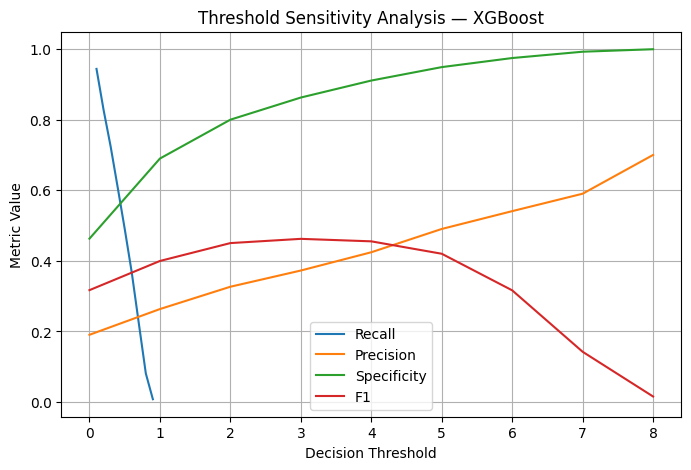

In [82]:
plt.figure(figsize=(8,5))
plt.plot(df_sens["threshold"], df_sens["recall_sensitivity"], label="Recall")
plt.plot(df_sens["precision"], label="Precision")
plt.plot(df_sens["specificity"], label="Specificity")
plt.plot(df_sens["f1"], label="F1")
plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")
plt.title("Threshold Sensitivity Analysis — XGBoost")
plt.legend()
plt.grid(True)
plt.show()


## Descriptive Statistics (Summary Table)
- Table summarizing the dataset across demographic groups, ethnic backgrounds, and key comorbid conditions
- It will save an excel files in **./data/output/**<br>

In [ ]:
import sys
PROJECT_ROOT = Path('.').resolve()          
sys.path.append(str(PROJECT_ROOT))
from utils.summary_table_utils import generate_split_summary
OUTPUT_DIR = PROJECT_ROOT / "data" / "output"

summary_df = generate_split_summary(OUTPUT_DIR, fold=0, save_excel=True)
summary_df

,Training Set,Validation Set,Test Set
Age (Mean (SD)),63.27 (16.81),62.82 (17.30),62.93 (17.28)
Male,14382 (56.1%),2588 (57.2%),4182 (55.5%)
ethnicity: AMERICAN INDIAN/ALASKA NATIVE,59 (0.2%),7 (0.2%),23 (0.3%)
ethnicity: ASIAN,262 (1.0%),56 (1.2%),106 (1.4%)
ethnicity: ASIAN - ASIAN INDIAN,70 (0.3%),10 (0.2%),14 (0.2%)
ethnicity: ASIAN - CHINESE,258 (1.0%),35 (0.8%),77 (1.0%)
ethnicity: ASIAN - KOREAN,13 (0.1%),2 (0.0%),8 (0.1%)
ethnicity: ASIAN - SOUTH EAST ASIAN,107 (0.4%),14 (0.3%),37 (0.5%)
ethnicity: BLACK/AFRICAN,112 (0.4%),15 (0.3%),30 (0.4%)
ethnicity: BLACK/AFRICAN AMERICAN,2079 (8.1%),401 (8.9%),651 (8.6%)


# EDA
Distribution of cohort

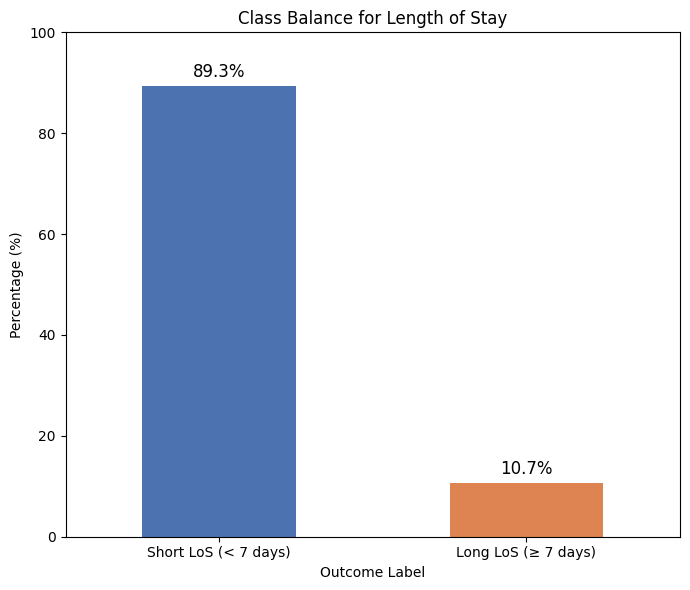

In [48]:
# Define path
SCRIPT_DIR = Path('.')
PROJECT_ROOT = SCRIPT_DIR.parent
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'cohort'
# Load 
df = pd.read_csv(OUTPUT_DIR / 'cohort_icu_length_of_stay_7_.csv')

# Compute class balance
label_counts = df['label'].value_counts().sort_index()  # ensure 0 then 1
total_count = label_counts.sum()

label_percentages = ((label_counts / total_count) * 100).round(1)

plot_data = label_percentages   
 
# Barplot
plt.figure(figsize=(7, 6))
plot_data.plot(kind='bar', color=['#4C72B0', '#DD8452'])

plt.title('Class Balance for Length of Stay')
plt.xlabel('Outcome Label')
plt.ylabel('Percentage (%)')
plt.xticks(ticks=[0, 1],labels=['Short LoS (< 7 days)', 'Long LoS (≥ 7 days)'],rotation=0)
plt.ylim(0, 100)

# Add % text above bars
for i, percentage in enumerate(plot_data):
    plt.text(i, percentage + 1, f'{percentage:.1f}%', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

## 10. Explainable AI Methods
full interactive Explainable AI dashboard. 
- It builds the UI components—including patient slider, local explanation buttons (LIME, SHAP, DiCE), global explanation buttons (PDP, ALE, Beeswarm), and an output console—and registers all callback functions for generating visual explanations.

In [ ]:
import importlib
import xai_manager  # <-- import module first

importlib.reload(xai_manager)
from xai_manager import XAIManager
import importlib, xai_manager
importlib.reload(xai_manager)
from xai_manager import XAIManager
xai = XAIManager(ml)


# Scrollable DataFrame helper (needed for DiCE)
def scrollable(df, height='250px', width='100%'):
    """
    Return a DataFrame wrapped in a scrollable HTML <div>.
    Works reliably inside ipywidgets.Output or notebook cells.
    """
    html = f"""
<div style="border:1px solid #e0e0e0; padding:5px;
            height:{height}; width:{width};
            overflow-x:auto; overflow-y:auto;">
{df.to_html(max_rows=50, max_cols=30)}
</div>
"""
    return HTML(html)

if 'ml' not in globals():
    print("⚠️ Please run training first to create `ml` (ML_models instance).")
else:
    # XAI manager
    xai = XAIManager(ml)

    # UI LAYOUT
    header = widgets.HTML(
        f"<h3>XAI Dashboard: "
        f"<span style='color:#2c3e50'>{ml.model_type}</span></h3>")
    # Patient index Slider
    max_p = len(ml.X_test_df) - 1
    slider_patient = widgets.IntSlider(value=0, min=0, max=100, step=1,description='Sample', layout=widgets.Layout(width='60%'))
    # Local widgets
    btn_lime = widgets.Button(description='LIME (Local)',button_style='info')
    btn_shap_interpret = widgets.Button(description='Kernel SHAP (interpret)',button_style='warning')
    btn_waterfall = widgets.Button(description='SHAP Waterfall',button_style='primary')
    btn_force = widgets.Button(description='SHAP Force',button_style='primary')
    btn_dice = widgets.Button(description='Counterfactuals (DiCE)',button_style='danger')
    # Global widgets
    btn_pdp = widgets.Button(description='PDP (Alibi)',button_style='success')
    btn_ale = widgets.Button(description='ALE (Alibi)',button_style='danger')
    out_console = widgets.Output(layout={'border': '1px solid #e0e0e0','padding': '10px','height': '500px','overflow_y': 'scroll'})
    btn_beeswarm = widgets.Button(description='Beeswarm (SHAP)',button_style='info')

    row_local = widgets.HBox([btn_lime, btn_shap_interpret, btn_waterfall, btn_force, btn_dice])
    row_global = widgets.HBox([btn_pdp, btn_ale, btn_beeswarm])
    dashboard = widgets.VBox([header,slider_patient, widgets.HTML("<b>Local:</b>"),row_local, widgets.HTML("<b>Global:</b>"),row_global, widgets.HTML("<hr>"),out_console])
    display(dashboard)

    def is_tree_model():
        """Decide whether to use TreeExplainer or KernelExplainer."""
        return ml.model_type.lower().strip() in ["xgboost","random forest","gradient boosting"]

    # LIME (local)
    def on_click_lime(b):
        out_console.clear_output()
        with out_console:
            try:
                from interpret import show
                idx = slider_patient.value
                print(f"⏳ Generating LIME explanations (interpret) for patient index {idx}...")

                lime_view = xai.local_lime_interpret_instance(instance_idx=idx)
                display(show(lime_view))   # single-instance LIME, no 'Overall' table

            except Exception:
                print("❌ Error in LIME calculation:")
                print(traceback.format_exc())

    # SHAP Waterfall 
    def on_click_waterfall(b):
        out_console.clear_output()
        with out_console:
            try:
                idx = slider_patient.value
                print(f"⏳ Generating SHAP Waterfall for patient index {idx}...")
                if is_tree_model():
                    xai.local_shap_tree_waterfall(instance_idx=idx)
                else:
                    xai.local_shap_kernel_waterfall(instance_idx=idx)
                plt.show()
            except Exception:
                print("❌ Error in SHAP Waterfall:")
                print(traceback.format_exc())

    # SHAP Force 
    def on_click_force(b):
        out_console.clear_output()
        with out_console:
            try:
                idx = slider_patient.value
                print(f"⏳ Generating SHAP Force plot (JS) for patient index {idx}...")

                n_test = idx + 1

                if is_tree_model():
                    # TreeExplainer for XGBoost / tree models
                    shap_values, _ = xai.local_shap_tree(n_test=n_test)
                else:
                    # KernelExplainer for Logistic Regression / Linear SVM
                    shap_values, _ = xai.local_shap_kernel_model(
                        n_background=100,
                        n_test=n_test)

                force_vis = shap.plots.force(shap_values[idx])
                display(force_vis)

            except Exception:
                print("❌ Error in SHAP Force plot:")
                print(traceback.format_exc())

    # Kernel SHAP from interpret 
    def on_click_shap_interpret(b):
        out_console.clear_output()
        with out_console:
            try:
                from interpret import show
                idx = slider_patient.value
                print(f"⏳ Generating Kernel SHAP (interpret) for patient index {idx}...")
                shap_local = xai.local_shap_kernel_interpret_instance(instance_idx=idx)
                display(show(shap_local))
            except Exception:
                print("❌ Error in interpret Kernel SHAP:")
                print(traceback.format_exc())

    # Counterfactuals (DiCE)
    def on_click_dice(b):
        out_console.clear_output()
        with out_console:
            try:
                idx = slider_patient.value
                print(f"⏳ Generating DiCE counterfactuals for patient index {idx}...")

                cf = xai.local_counterfactuals_dice(instance_idx=idx, total_CFs=5)

                # DataFrames
                orig_df = cf.cf_examples_list[0].test_instance_df
                cf_df   = cf.cf_examples_list[0].final_cfs_df
                changed_df = cf_df.loc[:, (cf_df != orig_df.iloc[0]).any()]

                # Display
                print("🔹 Original instance")
                display(scrollable(orig_df))

                print("\n🔹 Counterfactuals (changed features only)")
                display(scrollable(changed_df))

                # Save outputs
                cf_df.to_csv("dice_counterfactuals.csv", index=False)
                changed_df.to_csv("dice_counterfactuals_changed_only.csv", index=False)

                print("\n💾 Saved:")
                print(" - dice_counterfactuals.csv")
                print(" - dice_counterfactuals_changed_only.csv")

            except Exception:
                print("❌ Error in DiCE counterfactuals:")
                print(traceback.format_exc())

    # Global PDP (alibi)
    def on_click_pdp(b):
        out_console.clear_output()
        with out_console:
            try:
                print("⏳ Generating PDP Plot (Alibi)...")
                print("Note: Showing top 4 numeric features to prevent clutter.")

                # Choose a small subset of numeric features (similar strategy as ALE)
                feature_names = list(ml.X_train_df.columns)
                numeric_cols = ml.X_train_df.select_dtypes(include=[np.number]).columns.tolist()
                top_numeric = numeric_cols[:4]
                feat_indices = [feature_names.index(col) for col in top_numeric]

                # This will compute PD and call plot_pd(exp, features=feat_indices) internally
                xai.global_pdp_alibi(feature_indices=feat_indices)
                plt.show()
            except Exception:
                print("❌ Error in PDP (Alibi) calculation:")
                print(traceback.format_exc())

    # Global ALE (alibi)
    def on_click_ale(b):
        out_console.clear_output()
        with out_console:
            try:
                print("⏳ Generating ALE Plot (Alibi)...")
                print("Note: Showing top 4 numeric features to prevent clutter.")

                feature_names = list(ml.X_train_df.columns)
                numeric_cols = ml.X_train_df.select_dtypes(include=[np.number]).columns.tolist()
                top_numeric = numeric_cols[:4]
                feat_indices = [feature_names.index(col) for col in top_numeric]

                xai.global_ale_alibi(feature_indices=feat_indices)
                plt.show()
            except Exception:
                print("❌ Error in ALE calculation:")
                print(traceback.format_exc())

        #  Global SHAP Beeswarm 
    def on_click_beeswarm(b):
        out_console.clear_output()
        with out_console:
            try:
                print("⏳ Generating SHAP Beeswarm (global feature importance)...")

                xai.global_shap_beeswarm(n_test=200, n_background=100)
                plt.show()
            except Exception:
                print("❌ Error in SHAP Beeswarm:")
                print(traceback.format_exc())

    # Link Buttons
    btn_lime.on_click(on_click_lime)
    btn_waterfall.on_click(on_click_waterfall)
    btn_force.on_click(on_click_force)
    btn_shap_interpret.on_click(on_click_shap_interpret)
    btn_dice.on_click(on_click_dice)
    btn_pdp.on_click(on_click_pdp)
    btn_ale.on_click(on_click_ale)
    btn_beeswarm.on_click(on_click_beeswarm) 

⚠️ Please run training first to create `ml` (ML_models instance).


## 11. FAIRNESS EVALUATION (demograhic parity and equalized odds)
In train and testing step we save output files in **./data/output/** folder.

This file conatins list of demographic variables included in training and testing of the model.

It also contains the ground truth labels and predicted probability for each sample.

We use the above saved data to perform fairness evaluation of the results obtained from model testing.

This module can be used as stand-alone module also.

Please create a file that contains predicted probabilites form the last sigmoid layer in column named **Prob** and
ground truth labels for each sample in column named **Labels**.

In [27]:
fairness.fairness_evaluation(inputFile='outputDict',outputFile='fairnessReport')

Using Fairlearn's MetricFrame for fairness evaluation.


,sensitive_attribute,sensitive_feature_0,tp,tn,fp,fn,tpr,tnr,fpr,fnr,pr,nr,accuracy
0,ethnicity,AMERICAN INDIAN/ALASKA NATIVE,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.800000
1,ethnicity,ASIAN,0.000000,24.000000,1.000000,1.000000,0.000000,0.960000,0.040000,1.000000,0.038462,0.961538,0.923077
2,ethnicity,ASIAN - ASIAN INDIAN,0.000000,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.666667
3,ethnicity,ASIAN - CHINESE,2.000000,12.000000,1.000000,1.000000,0.666667,0.923077,0.076923,0.333333,0.187500,0.812500,0.875000
4,ethnicity,ASIAN - KOREAN,0.000000,1.000000,0.000000,0.000000,nan,1.000000,0.000000,nan,0.000000,1.000000,1.000000
5,ethnicity,ASIAN - SOUTH EAST ASIAN,0.000000,3.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.750000
6,ethnicity,BLACK/AFRICAN,0.000000,5.000000,0.000000,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.714286
7,ethnicity,BLACK/AFRICAN AMERICAN,3.000000,96.000000,4.000000,14.000000,0.176471,0.960000,0.040000,0.823529,0.059829,0.940171,0.846154
8,ethnicity,BLACK/CAPE VERDEAN,0.000000,6.000000,1.000000,2.000000,0.000000,0.857143,0.142857,1.000000,0.111111,0.888889,0.666667
9,ethnicity,BLACK/CARIBBEAN ISLAND,1.000000,5.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.166667,0.833333,1.000000


Fairness report saved to: ./data/output/fairnessReport.csv


In [34]:
# Load
output_dict = pickle.load(open("./data/output/outputDict", "rb"))
output_dict = pd.DataFrame(output_dict)

# Ensure Predicted
if "Predicted" not in output_dict.columns:
    output_dict["Predicted"] = (output_dict["Prob"] >= 0.5).astype(int)

# Ensure age bins
if "age_binned" not in output_dict.columns and "age" in output_dict.columns:
    output_dict["age_binned"] = output_dict["age"].apply(
        lambda x: "{}-{}".format((x//10)*10, (x//10 + 1)*10))

# Sensitive attributes
sensitive_attrs = ["ethnicity", "gender", "age_binned"]
if "insurance" in output_dict.columns:
    sensitive_attrs.append("insurance")

# Compute metrics
all_metrics = {}
for attr in sensitive_attrs:
    mf = MetricFrame(
        metrics={"demographic_parity (selection_rate)": selection_rate,"true_positive_rate": true_positive_rate,"false_positive_rate (overdiagnosis)": false_positive_rate,
            "false_negative_rate (underdiagnosis)": false_negative_rate},
        y_true=output_dict["Labels"],
        y_pred=output_dict["Predicted"],
        sensitive_features=output_dict[attr])
    # Store by_group table for this attribute
    all_metrics[attr] = mf.by_group
    
# all_metrics is a dict:
#   all_metrics["ethnicity"] -> DP, TPR, FPR, FNR by ethnicity
#   all_metrics["gender"]    -> same by gender
#   all_metrics["age_binned"] / ["insurance"] if present
all_metrics

rows = []

for attr, df in all_metrics.items():
    temp = df.copy()
    temp["sensitive_attr"] = attr
    temp["group"] = temp.index
    rows.append(temp.reset_index(drop=True))

fairness_long = pd.concat(rows, axis=0, ignore_index=True)

fairness_long.to_csv("./data/output/fairness_metrics_long.csv", index=False)
print("Saved: ./data/output/fairness_metrics_long.csv")


Saved: ./data/output/fairness_metrics_long.csv


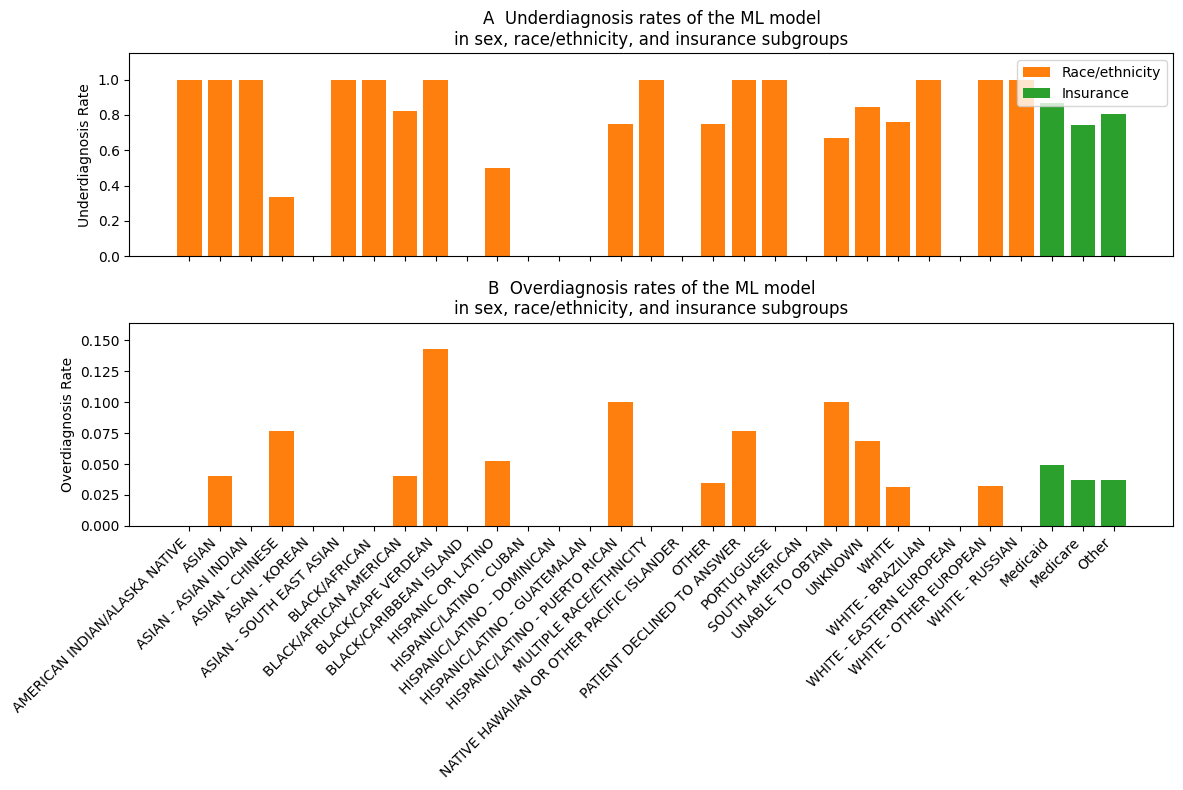

In [ ]:
# ---- choose which sensitive attributes to show together ----
attrs_to_plot = ["ethnicity", "insurance"]  # adjust if needed

# keep only these
plot_df = fairness_long[fairness_long["sensitive_attr"].isin(attrs_to_plot)].copy()

# nice readable names for legend / titles
attr_labels = {
    "ethnicity": "Race/ethnicity",
    "insurance": "Insurance"
}

# colors for each attribute group (change if you like)
attr_colors = {
    "ethnicity": "C1",
    "insurance": "C2"
}

# metric column names from your MetricFrame
metric_under = "false_negative_rate (underdiagnosis)"
metric_over  = "false_positive_rate (overdiagnosis)"

# helper to prepare bar data in order: gender groups, then ethnicity, then insurance
def prepare_bars(metric_col):
    heights = []
    labels = []
    colors = []
    for attr in attrs_to_plot:
        tmp = plot_df[plot_df["sensitive_attr"] == attr].copy()
        # sort groups alphabetically (or customize if you want a specific order)
        tmp = tmp.sort_values("group")
        heights.extend(tmp[metric_col].values)
        labels.extend(tmp["group"].tolist())
        colors.extend([attr_colors[attr]] * len(tmp))
    return heights, labels, colors

heights_under, labels_under, colors_under = prepare_bars(metric_under)
heights_over,  labels_over,  colors_over  = prepare_bars(metric_over)

# ---- plotting ----
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Panel A: underdiagnosis
x_pos = range(len(heights_under))
axes[0].bar(x_pos, heights_under, color=colors_under)
axes[0].set_ylabel("Underdiagnosis Rate")
axes[0].set_title("A  Underdiagnosis rates of the ML model\nin sex, race/ethnicity, and insurance subgroups")
axes[0].set_ylim(0, max(heights_under) * 1.15)

# Panel B: overdiagnosis
axes[1].bar(x_pos, heights_over, color=colors_over)
axes[1].set_ylabel("Overdiagnosis Rate")
axes[1].set_title("B  Overdiagnosis rates of the ML model\nin sex, race/ethnicity, and insurance subgroups")
axes[1].set_ylim(0, max(heights_over) * 1.15)

# shared x-axis labels
axes[1].set_xticks(list(x_pos))
axes[1].set_xticklabels(labels_over, rotation=45, ha="right")

# build legend from attribute colors
legend_handles = [Patch(facecolor=attr_colors[a], label=attr_labels.get(a, a))
                  for a in attrs_to_plot]
axes[0].legend(handles=legend_handles, loc="upper right")

plt.tight_layout()
plt.show()


## 12. Distribution Shift
This cell defines utilities to compare the first 10% and last 10% of the cohort over admission time, quantifying dataset shift between early and late periods. It computes an overall distribution shift using MMD on numeric features, checks outcome (extended LOS) prevalence drift, highlights the top drifting features via KS statistics, and summarizes demographic shifts (ethnicity, gender, insurance). The results help you assess temporal drift and fairness risks that may affect model performance and stability over time.

Total rows: 8511
Early period: 2110-01-11 → 2111-08-05
Late period : 2120-12-27 → 2121-12-31
Using 1 numeric feature columns.

=== OVERALL MMD (Early 10% vs Late 10%) ===
MMD = 0.003354974735974049

=== LABEL SHIFT ===
Extended LOS prevalence (early): 0.10928319623971798
Extended LOS prevalence (late) : 0.1128084606345476


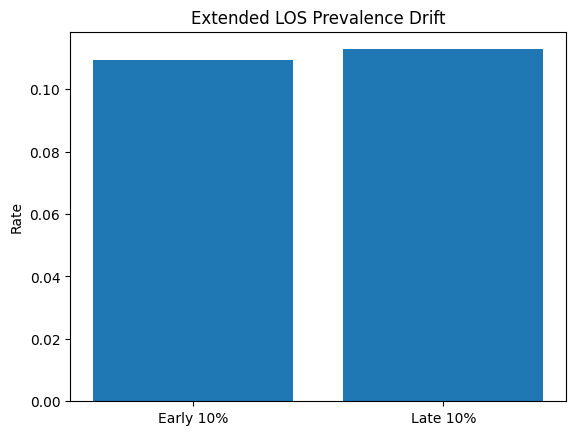


=== TOP 15 FEATURES WITH LARGEST DRIFT (KS) ===
Age                            KS = 0.043

=== ETHNICITY SHIFT ===
                                              early      late      diff
ethnicity                                                              
WHITE                                      0.614571  0.645123  0.030552
ASIAN - SOUTH EAST ASIAN                   0.001175  0.009401  0.008226
BLACK/AFRICAN AMERICAN                     0.069330  0.077556  0.008226
BLACK/AFRICAN                              0.001175  0.008226  0.007051
BLACK/CARIBBEAN ISLAND                     0.003525  0.008226  0.004700
WHITE - BRAZILIAN                          0.004700  0.008226  0.003525
WHITE - RUSSIAN                            0.002350  0.005875  0.003525
BLACK/CAPE VERDEAN                         0.002350  0.005875  0.003525
NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER  0.000000  0.003525  0.003525
HISPANIC/LATINO - PUERTO RICAN             0.014101  0.017626  0.003525
ASIAN - CHINESE     

In [37]:
from utils.drift_util import analyze_early_late_shift
# Load your cohort dataframe
df = pd.read_csv("data/cohort/cohort_icu_length_of_stay_7_.csv")
# Run drift analysis
results = analyze_early_late_shift(df, time_col="intime")